# ML LAB-6
# Name: Sneha Kanjwani
# CMS ID: 023-24-0273
# Section: H
# GitHub: https://github.com/snehakanjwani30/Machine-Learning-Labs
# Kaggle: https://www.kaggle.com/snehakanjwani
# Dataset: Telco Customer Churn (cleaned in Lab 2)
# Dataset Source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# Part 1 — Problem Definition & Dataset Verification

In [1]:
# TASK-1
import pandas as pd
import numpy as np
df = pd.read_csv('clean_churn.csv')
print('Dataset shape:',df.shape)
print('Data types:')
print(df.dtypes)
#The Telco Customer Churn dataset was loaded successfully from `clean_churn.csv`. 
#The dataset contains 7,021 rows and 20 columns. The data types were checked to 
#understand the different types of variables in the dataset. This confirms that 
#the dataset is ready for further preprocessing and model training.


Dataset shape: (7021, 20)
Data types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


# TASK-2
In Lab 3, the Decision Tree achieved an accuracy of 0.787189, precision of 0.651452, recall of 0.422043, and F1-score of 0.512235.
In Lab 4, the Random Forest achieved an accuracy of 0.774377, precision of 0.603774, recall of 0.430108, and F1-score of 0.502355. 
These results will be used as benchmarks for comparing Logistic Regression and KNN in this lab.

# Part 2 — Feature Scaling & Preparation

In [2]:
# TASK-3
from sklearn.model_selection import train_test_split
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop('Churn', axis=1)
y = df['Churn']
X = pd.get_dummies(X, drop_first=True, dtype=int)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nMissing values:", X.isnull().sum().sum())
#The Churn column was converted into numerical values, where No is represented by 0 
#and Yes by 1. The Churn column was then separated from the other features to create 
#X and y. Categorical features in X were converted into numerical columns using 
#one-hot encoding. The output shapes and missing values were checked to make sure 
#the data was ready for model training.

X shape: (7021, 30)
y shape: (7021,)

Missing values: 0


# TASK-4
Feature scaling is important for KNN because KNN uses distances between data points, so features with larger values could dominate the distance calculation. Scaling also helps Logistic Regression by putting features on a similar scale. Decision Trees and Random Forests do not require scaling because they make decisions using feature splits rather than distance calculations.

In [3]:
# TASK-5
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('X_train shape:',X_train.shape)
print('X_test shape:',X_test.shape)
print('y_train shape:',y_train.shape)
print('y_test shape:',y_test.shape)

X_train shape: (5616, 30)
X_test shape: (1405, 30)
y_train shape: (5616,)
y_test shape: (1405,)


In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling completed.")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)
#The dataset was divided into training and testing sets using an 80:20 ratio, while 
#`stratify=y` maintained a similar class distribution in both sets. StandardScaler was 
#then used to scale the features. The scaler was fitted only on the training data and 
#then used to transform both the training and testing data. This prevents information 
#from the test set from being used during scaling and helps avoid data leakage.


Scaling completed.
Scaled training shape: (5616, 30)
Scaled testing shape: (1405, 30)


# Part 3 — Logistic Regression

In [5]:
# TASK-6
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)
print('Logistic Regression predictions generated successfully!')
#The Logistic Regression model was trained using the scaled training data. Predictions were then generated for the scaled test data to evaluate 
#how well the model predicts customer churn.

Logistic Regression predictions generated successfully!


In [6]:
# TASK-7
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
logreg_precision = precision_score(y_test, y_pred_logreg)
logreg_recall = recall_score(y_test, y_pred_logreg)
logreg_f1 = f1_score(y_test, y_pred_logreg)
print("Logistic Regression Results")
print("Accuracy :", logreg_accuracy)
print("Precision:", logreg_precision)
print("Recall   :", logreg_recall)
print("F1-score :", logreg_f1)

Logistic Regression Results
Accuracy : 0.80355871886121
Precision: 0.6621621621621622
Recall   : 0.5268817204301075
F1-score : 0.5868263473053892


Confusion Matrix:
[[933 100]
 [176 196]]


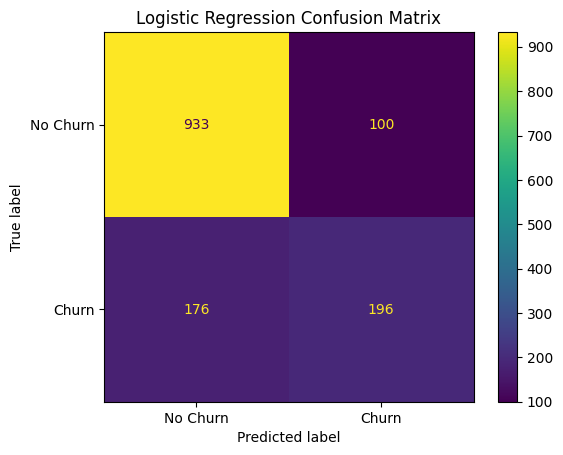

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
print("Confusion Matrix:")
print(cm_logreg)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg,
    display_labels=['No Churn', 'Churn']
)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()
#The Logistic Regression model achieved 80.36% accuracy, 66.22% precision, 52.69% recall, and an F1-score of 58.68%. 
#The confusion matrix shows that the model correctly identified 196 churn customers and 933 non-churn customers. However, it 
#missed 176 actual churn customers, so there is still room to improve churn detection.


In [9]:
# TASK-8
probabilities = logreg.predict_proba(X_test_scaled[:10])
print(probabilities)
prob_df = pd.DataFrame(probabilities,
                      columns=['Probability_No_Churn', 'Probability_Churn'])
print(prob_df)
#The predict_proba() results show the estimated probability of each customer 
#belonging to the No Churn or Churn class. For example, the first customer has a 
#75.89% probability of Churn, while the third customer has a 28.39% probability of Churn. 
#The predict() function uses the higher class probability to make the final 
#Yes/No churn prediction.

[[0.24108696 0.75891304]
 [0.3852258  0.6147742 ]
 [0.71605066 0.28394934]
 [0.9513982  0.0486018 ]
 [0.99097454 0.00902546]
 [0.67019151 0.32980849]
 [0.84525122 0.15474878]
 [0.20769143 0.79230857]
 [0.98250254 0.01749746]
 [0.98488292 0.01511708]]
   Probability_No_Churn  Probability_Churn
0              0.241087           0.758913
1              0.385226           0.614774
2              0.716051           0.283949
3              0.951398           0.048602
4              0.990975           0.009025
5              0.670192           0.329808
6              0.845251           0.154749
7              0.207691           0.792309
8              0.982503           0.017497
9              0.984883           0.015117


# Part 4 — KNN & Choosing K

In [10]:
# TASK-9
from sklearn.neighbors import KNeighborsClassifier
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_results = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    knn_results.append({
        'K': k,
        'Accuracy': accuracy,
        'F1-score': f1
    })
knn_results_df = pd.DataFrame(knn_results)
knn_results_df

,K,Accuracy,F1-score
0,1,0.718861,0.469799
1,3,0.736655,0.481793
2,5,0.752313,0.500000
3,7,0.771530,0.536797
4,9,0.774377,0.543885
5,11,0.773665,0.544413
6,15,0.784342,0.570213
7,21,0.779359,0.560907


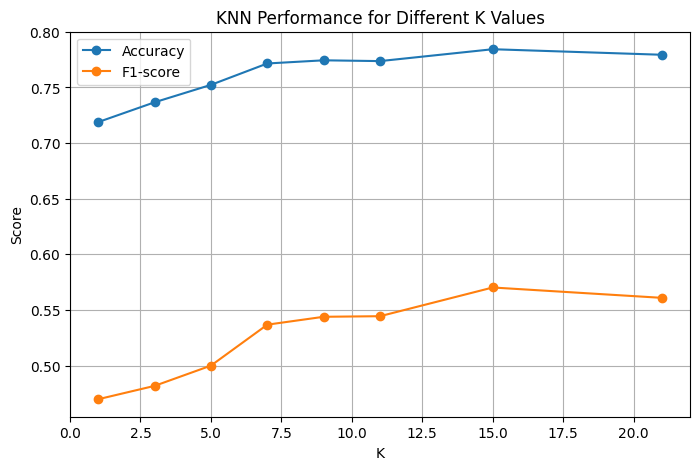

In [11]:
# TASK-10
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(knn_results_df['K'], knn_results_df['Accuracy'],
         marker='o', label='Accuracy')
plt.plot(knn_results_df['K'], knn_results_df['F1-score'],
         marker='o', label='F1-score')
plt.xlabel('K')
plt.ylabel('Score')
plt.title('KNN Performance for Different K Values')
plt.legend()
plt.grid(True)
plt.show()
#The plot shows that KNN performance generally improves as K increases, with the 
#highest accuracy and F1-score at K = 15. Therefore, K = 15 is selected because it 
#gives the best performance among the tested values. A very small K can be sensitive 
#to noise and individual observations, while a very large K can make the model too 
#general. K = 15 provides a good balance and the strongest results in this experiment.

In [12]:
# TASK-11
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
knn_final = KNeighborsClassifier(n_neighbors=15)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1-score:", knn_f1)
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:")
print(cm_knn)
#The KNN model with K = 15 achieved 78.43% accuracy, 60.36% precision, 54.03% recall, 
#and a 57.02% F1-score. The confusion matrix shows that the model correctly predicted 
#901 non-churn customers and 201 churn customers. It incorrectly predicted 132 non-churn 
#customers as churn and missed 171 actual churn customers. Overall, the model provides 
#a reasonable result but still misses some customers who are likely to churn.

Accuracy: 0.7843416370106762
Precision: 0.6036036036036037
Recall: 0.5403225806451613
F1-score: 0.5702127659574469
Confusion Matrix:
[[901 132]
 [171 201]]


# Part 5 — Model Comparison (4 Models)

In [13]:
# TASK-12
comparison_df = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest',
        'Logistic Regression',
        'KNN'
    ],
    'Accuracy': [
        0.787189,
        0.774377,
        0.80355871886121,
        0.7843416370106762
    ],
    'Precision': [
        0.651452,
        0.603774,
        0.6621621621621622,
        0.6036036036036037
    ],
    'Recall': [
        0.422043,
        0.430108,
        0.5268817204301075,
        0.5403225806451613
    ],
    'F1-score': [
        0.512235,
        0.502355,
        0.5868263473053892,
        0.5702127659574469
    ]
})

comparison_df
#The comparison shows that Logistic Regression has the highest accuracy, precision, 
#and F1-score among the four models. KNN has the highest recall, meaning it identifies 
#more of the actual churn customers than the other models. Decision Tree and Random 
#Forest have lower recall and F1-scores in this experiment. Therefore, the model 
#performance differs depending on which evaluation metric is considered.

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.787189,0.651452,0.422043,0.512235
1,Random Forest,0.774377,0.603774,0.430108,0.502355
2,Logistic Regression,0.803559,0.662162,0.526882,0.586826
3,KNN,0.784342,0.603604,0.540323,0.570213


# TASK-13
Logistic Regression achieved the highest accuracy, precision, and F1-score among the four models, while KNN achieved the highest recall. This shows that the model ranking changes depending on the evaluation metric being considered. Since the dataset contains more non-churn than churn customers, accuracy alone may not give a complete picture of model performance. In this case, F1-score is an important metric because it considers both precision and recall, while recall is also important when the goal is to identify as many churn customers as possible.


# Part 6 — Coefficient Interpretation

In [14]:
# TASK-14
import numpy as np
import pandas as pd
coefficients = logreg.coef_[0]
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Odds Ratio': np.exp(coefficients)
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
coef_df[['Feature', 'Coefficient', 'Odds Ratio']].head(10)

#The Logistic Regression coefficients show how different features are associated 
#with customer churn. Tenure has a negative coefficient and an odds ratio of 0.244, 
#indicating lower churn odds as tenure increases. TotalCharges has a positive coefficient 
#with an odds ratio of 1.958, indicating higher churn odds as TotalCharges increases. 
#InternetService_Fiber optic has an odds ratio of 1.864, showing higher churn odds 
#compared with the reference internet-service category. Contract_Two year has a negative 
#coefficient and an odds ratio of 0.559, indicating lower churn odds compared with the 
#reference contract category. MultipleLines_Yes has an odds ratio of 1.206, indicating 
#higher churn odds compared with the reference category.

,Feature,Coefficient,Odds Ratio
1,tenure,-1.410222,0.244089
3,TotalCharges,0.672041,1.958229
10,InternetService_Fiber optic,0.622899,1.864325
25,Contract_Two year,-0.580891,0.559400
2,MonthlyCharges,-0.535421,0.585423
24,Contract_One year,-0.272067,0.761803
9,MultipleLines_Yes,0.187062,1.205702
23,StreamingMovies_Yes,0.186698,1.205263
21,StreamingTV_Yes,0.174692,1.190879
26,PaperlessBilling_Yes,0.166466,1.181124


# TASK-15
The Logistic Regression results show that tenure, TotalCharges, Internet Service, and contract type have noticeable relationships with churn. These findings can be compared with the Lab 2 EDA results, where customer tenure, monthly charges, and contract-related factors were also useful for understanding churn patterns. The Decision Tree feature importances from Lab 3 can also be compared with these features to see where the models agree. Some differences are expected because Logistic Regression measures the direction and strength of feature relationships using coefficients, while a Decision Tree measures how useful features are for making splits. Overall, the comparison shows that several important churn-related features are identified by more than one analysis method.


# Part 7 — Final Model Selection & Conclusion

# TASK-16
Based on the comparison, Logistic Regression is selected as the final model because it achieved the highest accuracy, precision, and F1-score among the four models. It also provides a useful balance between correctly identifying churn customers and avoiding incorrect churn predictions. However, the final choice should also be supported by cross-validation, as seen in Lab 4, to check that the model performs consistently on different training and validation splits.


# TASK-17
In this lab, Logistic Regression and KNN were applied to the Telco Customer Churn dataset. The features were scaled using StandardScaler before training the models because scaling is important for distance-based and coefficient-based models. Different K values were tested for KNN, and K = 15 gave the highest F1-score among the tested values. Logistic Regression achieved the highest accuracy, precision, and F1-score in the comparison, while KNN achieved the highest recall. The Logistic Regression coefficients and odds ratios also helped explain how different features were associated with churn. Overall, the lab showed that using multiple evaluation metrics gives a better understanding of classification model performance than using accuracy alone.
